# 03 — Sustainability Classification

**Owner:** Shravya

---

### Purpose
- Train a classification model (XGBoost) to classify sustainability levels
- Evaluate with accuracy, precision, recall, F1-score
- Generate SHAP explanations
- Save model and metrics

### Input
| File | Path |
|------|------|
| Processed dataset | `data/processed/final_dataset.csv` |

### Outputs
| File | Path | Description |
|------|------|-------------|
| Trained model | `models/sustainability_model.pkl` | XGBoost classifier |
| Metrics | `results/sustainability_metrics.csv` | Accuracy, F1, Precision, Recall |

### For Colab Users
```python
# After training, save and download:
import joblib
joblib.dump(model, "sustainability_model.pkl")
# Then upload .pkl to models/ and .csv to results/ on GitHub
```

In [62]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import time
import psutil

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from xgboost import XGBClassifier
import shap

from tensorflow import keras
from tensorflow.keras import layers

In [63]:
# ============================================================
# LOAD DATA
# ============================================================
# If running in Colab, upload final_dataset.csv or mount drive
# DATA_PATH = "final_dataset.csv"          # Colab
DATA_PATH = os.path.join("..", "data", "processed", "final_dataset.csv")  # Local

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (4445, 22)


,country,year,production,temperature_celsius,precip_mm,humidity,water_Salinity (ppt),water_pH,water_SecchiDepth (m),water_WaterDepth (m),...,genomic_GC_Content_global_mean,genomic_AT_Content_global_mean,genomic_Sequence_Length_global_mean,genomic_Num_A_global_mean,genomic_Num_T_global_mean,genomic_Num_C_global_mean,genomic_Num_G_global_mean,genomic_kmer_3_freq_global_mean,genomic_Mutation_Flag_global_mean,genomic_Disease_Risk_global_mode
0,Afghanistan,2000,300.0,0.0,0.0,0.0,-0.245685,1.779226,0.440285,-0.118110,...,4.985642e-16,-4.985642e-16,0.0,-2.013204e-17,2.368476e-16,-2.936910e-16,6.898186e-17,2.842171e-17,1.604642e-16,High
1,Afghanistan,2001,450.0,0.0,0.0,0.0,0.537905,2.195447,-0.401176,-1.433756,...,4.985642e-16,-4.985642e-16,0.0,-2.013204e-17,2.368476e-16,-2.936910e-16,6.898186e-17,2.842171e-17,1.604642e-16,High
2,Afghanistan,2002,450.0,0.0,0.0,0.0,0.670393,0.450484,0.143565,-0.102408,...,4.985642e-16,-4.985642e-16,0.0,-2.013204e-17,2.368476e-16,-2.936910e-16,6.898186e-17,2.842171e-17,1.604642e-16,High
3,Afghanistan,2003,450.0,0.0,0.0,0.0,-0.335580,-0.895256,0.381796,0.493753,...,4.985642e-16,-4.985642e-16,0.0,-2.013204e-17,2.368476e-16,-2.936910e-16,6.898186e-17,2.842171e-17,1.604642e-16,High
4,Afghanistan,2004,450.0,0.0,0.0,0.0,-0.425552,-0.962568,0.548815,-0.451490,...,4.985642e-16,-4.985642e-16,0.0,-2.013204e-17,2.368476e-16,-2.936910e-16,6.898186e-17,2.842171e-17,1.604642e-16,High


In [64]:
# ============================================================
# SUSTAINABILITY SCORE (water quality + climate)
# ============================================================
# STEP 1: Select features (ignore genomic + production)
cols = [
    "water_pH",
    "water_Salinity (ppt)",
    "water_SecchiDepth (m)",
    "water_WaterTemp (C)",
    "water_AirTemp (C)",
    "temperature_celsius",
    "precip_mm",
    "humidity",
]
df_feat = df[cols].copy()

# STEP 2: Clean column names
df_feat = df_feat.rename(
    columns={
        "water_Salinity (ppt)": "salinity",
        "water_pH": "ph",
        "water_SecchiDepth (m)": "secchi_depth",
        "water_WaterTemp (C)": "water_temp",
        "water_AirTemp (C)": "air_temp",
    }
)

# STEP 3: Handle missing values (mean)
for c in df_feat.columns:
    df_feat[c] = pd.to_numeric(df_feat[c], errors="coerce")
    df_feat[c] = df_feat[c].fillna(df_feat[c].mean())

if df_feat.isna().any().any():
    raise ValueError("NaN values remain after mean imputation.")

# STEP 4: Normalize features (min-max)
ranges = {}
for c in df_feat.columns:
    min_val = df_feat[c].min()
    max_val = df_feat[c].max()
    if min_val == max_val:
        df_feat[c] = 0.5
        ranges[c] = 1.0
    else:
        df_feat[c] = (df_feat[c] - min_val) / (max_val - min_val)
        ranges[c] = max_val - min_val

# STEP 5: Convert to suitability scores (0-1)
ph_range = ranges["ph"]
salinity_range = ranges["salinity"]
water_temp_range = ranges["water_temp"]
air_temp_range = ranges["air_temp"]
climate_temp_range = ranges["temperature_celsius"]
rainfall_range = ranges["precip_mm"]
humidity_range = ranges["humidity"]

optimal_salinity = df["water_Salinity (ppt)"].mean()
optimal_temp = df["water_WaterTemp (C)"].mean()
optimal_rainfall = df["precip_mm"].mean()
optimal_humidity = df["humidity"].mean()

scores = pd.DataFrame(index=df.index)
scores["ph_score"] = 1 - (df["water_pH"] - 7.5).abs() / ph_range
scores["salinity_score"] = 1 - (df["water_Salinity (ppt)"] - optimal_salinity).abs() / salinity_range
scores["secchi_score"] = df_feat["secchi_depth"]
scores["water_temp_score"] = 1 - (df["water_WaterTemp (C)"] - optimal_temp).abs() / water_temp_range
scores["air_temp_score"] = 1 - (df["water_AirTemp (C)"] - optimal_temp).abs() / air_temp_range
scores["climate_temp_score"] = 1 - (df["temperature_celsius"] - optimal_temp).abs() / climate_temp_range
scores["rainfall_score"] = 1 - (df["precip_mm"] - optimal_rainfall).abs() / rainfall_range
scores["humidity_score"] = 1 - (df["humidity"] - optimal_humidity).abs() / humidity_range

scores = scores.clip(0, 1)
df = pd.concat([df, scores], axis=1)

print("Created suitability score columns:")
print(list(scores.columns))
df[scores.columns].head()

Created suitability score columns:
['ph_score', 'salinity_score', 'secchi_score', 'water_temp_score', 'air_temp_score', 'climate_temp_score', 'rainfall_score', 'humidity_score']


,ph_score,salinity_score,secchi_score,water_temp_score,air_temp_score,climate_temp_score,rainfall_score,humidity_score
0,0.0,0.795911,0.505288,0.707301,0.797764,0.925342,1.0,1.0
1,0.0,0.298104,0.000000,0.801048,0.590749,0.925342,1.0,1.0
2,0.0,0.213936,0.327111,0.925913,0.861853,0.925342,1.0,1.0
3,0.0,0.853020,0.470166,0.986841,0.627651,0.925342,1.0,1.0
4,0.0,0.910178,0.570459,0.991192,0.697009,0.925342,1.0,1.0


In [65]:
# ============================================================
# CLASSIFY SUSTAINABILITY SCORE (Low/Medium/High)
# ============================================================
if "sustainability_score" not in df.columns:
    score_cols = [c for c in df.columns if c.endswith("_score") and c != "sustainability_score"]
    if score_cols:
        df["sustainability_score"] = df[score_cols].mean(axis=1)
    else:
        raise ValueError("No sustainability_score found to classify.")

low_threshold = 0.4
high_threshold = 0.7

def _classify_score(val: float) -> str:
    if pd.isna(val):
        return "Medium"
    if val < low_threshold:
        return "Low"
    if val < high_threshold:
        return "Medium"
    return "High"

df["sustainability_class"] = df["sustainability_score"].apply(_classify_score)

print("Created sustainability_class with thresholds:")
print({"low": low_threshold, "high": high_threshold})
df[["sustainability_score", "sustainability_class"]].head()

Created sustainability_class with thresholds:
{'low': 0.4, 'high': 0.7}


,sustainability_score,sustainability_class
0,0.716451,High
1,0.576905,Medium
2,0.656769,Medium
3,0.732878,High
4,0.761773,High


In [66]:
# ============================================================
# FEATURE / TARGET SPLIT
# ============================================================
TARGET_COL = "sustainability_class"

target_cols = ["sustainability_class", "sustainability_score"]
X = df.drop(columns=target_cols, errors="ignore")
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
 )

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

X_train: (3556, 30), X_test: (889, 30)
y_train: (3556,), y_test: (889,)


In [67]:
# ============================================================
# METRICS STORE (Accuracy, Precision, Recall, F1)
# ============================================================
model_metrics = {}

In [77]:
# ============================================================
# MLP (Keras) CLASSIFICATION + TIMING + EVALUATION (fresh run)
# ============================================================
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

transformers = []
if num_cols:
    transformers.append(("num", StandardScaler(), num_cols))
if cat_cols:
    transformers.append(("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols))
if not transformers:
    raise ValueError("No features available for encoding/scaling.")

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop",
    sparse_threshold=0.0,
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)
num_classes = len(label_encoder.classes_)

input_dim = X_train_proc.shape[1]
model = keras.Sequential(
    [
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

start_time = time.time()
history = model.fit(
    X_train_proc,
    y_train_enc,
    epochs=25,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
)
train_time = time.time() - start_time

test_loss, test_acc = model.evaluate(X_test_proc, y_test_enc, verbose=0)
y_pred_enc = model.predict(X_test_proc, verbose=0).argmax(axis=1)

mlp_prec = precision_score(y_test_enc, y_pred_enc, average="macro", zero_division=0)
mlp_rec = recall_score(y_test_enc, y_pred_enc, average="macro", zero_division=0)
mlp_f1 = f1_score(y_test_enc, y_pred_enc, average="macro", zero_division=0)
model_metrics["MLP"] = {
    "accuracy": test_acc,
    "precision": mlp_prec,
    "recall": mlp_rec,
    "f1": mlp_f1,
}

print(f"Training time (s): {train_time:.2f}")
print(f"Test accuracy: {test_acc:.4f}")
print(classification_report(y_test_enc, y_pred_enc, target_names=label_encoder.classes_))

Epoch 1/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8935 - loss: 0.3421 - val_accuracy: 0.9986 - val_loss: 0.0570
Epoch 2/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9989 - loss: 0.0242 - val_accuracy: 1.0000 - val_loss: 0.0047
Epoch 3/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 0.0043 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 4/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 1.0000 - val_loss: 6.9043e-04
Epoch 5/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 1.0000 - val_loss: 3.7039e-04
Epoch 6/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 7.1782e-04 - val_accuracy: 1.0000 - val_loss: 2.3239e-04
Epoch 7/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 6.1072e-04 - val_accuracy: 1.0000 - val_loss: 1.5673e-04
Epoch 8/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 3.6291e-04 - val_

In [78]:
# ============================================================
# SAVE SUSTAINABILITY MODEL (MLP) TO .PKL
# ============================================================
models_dir = os.path.join("..", "models")
os.makedirs(models_dir, exist_ok=True)
model_path = os.path.join(models_dir, "sustainability_model.pkl")

# Save model + preprocessing + label encoder together
joblib.dump(
    {"model": model, "preprocessor": preprocessor, "label_encoder": label_encoder},
    model_path,
)
print(f"Saved model bundle to: {model_path}")

Saved model bundle to: ..\models\sustainability_model.pkl


In [76]:
# ============================================================
# 1D CNN (short sequence features) + TIMING + EVALUATION
# ============================================================
# Ensure dense arrays for CNN input
X_train_dense = np.asarray(X_train_proc)
X_test_dense = np.asarray(X_test_proc)

# Reshape to (samples, timesteps/features, channels)
X_train_cnn = X_train_dense.reshape(X_train_dense.shape[0], X_train_dense.shape[1], 1)
X_test_cnn = X_test_dense.reshape(X_test_dense.shape[0], X_test_dense.shape[1], 1)

cnn_model = keras.Sequential(
    [
        layers.Input(shape=(X_train_cnn.shape[1], 1)),
        layers.Conv1D(32, kernel_size=3, activation="relu", padding="same"),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(64, kernel_size=3, activation="relu", padding="same"),
        layers.GlobalMaxPooling1D(),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

cnn_start = time.time()
cnn_history = cnn_model.fit(
    X_train_cnn,
    y_train_enc,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
)
cnn_train_time = time.time() - cnn_start

cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test_enc, verbose=0)
cnn_pred = cnn_model.predict(X_test_cnn, verbose=0).argmax(axis=1)

cnn_prec = precision_score(y_test_enc, cnn_pred, average="macro", zero_division=0)
cnn_rec = recall_score(y_test_enc, cnn_pred, average="macro", zero_division=0)
cnn_f1 = f1_score(y_test_enc, cnn_pred, average="macro", zero_division=0)
model_metrics["1D CNN"] = {
    "accuracy": cnn_acc,
    "precision": cnn_prec,
    "recall": cnn_rec,
    "f1": cnn_f1,
}

print(f"CNN training time (s): {cnn_train_time:.2f}")
print(f"CNN test accuracy: {cnn_acc:.4f}")
print(classification_report(y_test_enc, cnn_pred, target_names=label_encoder.classes_))

Epoch 1/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8854 - loss: 0.3442 - val_accuracy: 0.9396 - val_loss: 0.1303
Epoch 2/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9887 - loss: 0.0509 - val_accuracy: 0.9986 - val_loss: 0.0092
Epoch 3/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9996 - loss: 0.0076 - val_accuracy: 1.0000 - val_loss: 0.0024
Epoch 4/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9996 - loss: 0.0031 - val_accuracy: 1.0000 - val_loss: 8.8464e-04
Epoch 5/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 3.7342e-04
Epoch 6/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 7.6677e-04 - val_accuracy: 1.0000 - val_loss: 2.1673e-04
Epoch 7/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 5.2858e-04 - val_accuracy: 1.0000 - val_loss: 1.8176e-04
Epoch 8/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 1.0000 - loss: 4.0741e-0

In [70]:
# ============================================================
# GRU (single layer, lightweight) + TIMING + EVALUATION
# ============================================================
# Reuse CNN-shaped inputs
X_train_gru = X_train_cnn
X_test_gru = X_test_cnn

gru_model = keras.Sequential(
    [
        layers.Input(shape=(X_train_gru.shape[1], 1)),
        layers.GRU(32),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

gru_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

gru_start = time.time()
gru_history = gru_model.fit(
    X_train_gru,
    y_train_enc,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
)
gru_train_time = time.time() - gru_start

gru_loss, gru_acc = gru_model.evaluate(X_test_gru, y_test_enc, verbose=0)
gru_pred = gru_model.predict(X_test_gru, verbose=0).argmax(axis=1)

gru_prec = precision_score(y_test_enc, gru_pred, average="macro", zero_division=0)
gru_rec = recall_score(y_test_enc, gru_pred, average="macro", zero_division=0)
gru_f1 = f1_score(y_test_enc, gru_pred, average="macro", zero_division=0)
model_metrics["GRU"] = {
    "accuracy": gru_acc,
    "precision": gru_prec,
    "recall": gru_rec,
    "f1": gru_f1,
}

print(f"GRU training time (s): {gru_train_time:.2f}")
print(f"GRU test accuracy: {gru_acc:.4f}")
print(classification_report(y_test_enc, gru_pred, target_names=label_encoder.classes_))

Epoch 1/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - accuracy: 0.7331 - loss: 0.5879 - val_accuracy: 0.7247 - val_loss: 0.5890
Epoch 2/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - accuracy: 0.7426 - loss: 0.5727 - val_accuracy: 0.7247 - val_loss: 0.5915
Epoch 3/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - accuracy: 0.7426 - loss: 0.5702 - val_accuracy: 0.7247 - val_loss: 0.5890
Epoch 4/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - accuracy: 0.7426 - loss: 0.5736 - val_accuracy: 0.7247 - val_loss: 0.5886
Epoch 5/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.7426 - loss: 0.5734 - val_accuracy: 0.7247 - val_loss: 0.5888
Epoch 6/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 10s 115ms/step - accuracy: 0.7426 - loss: 0.5720 - val_accuracy: 0.7247 - val_loss: 0.5888
Epoch 7/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 11s 119ms/step - accuracy: 0.7426 - loss: 0.5714 - val_accuracy: 0.7247 - val_loss: 0.5885
Epoch 8/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 9s 104ms/step - accuracy: 0.7426 - loss: 0.5720 - val_accuracy: 0.

c:\Users\deepa\Desktop\Aquaculture-MajorProject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\deepa\Desktop\Aquaculture-MajorProject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\deepa\Desktop\Aquaculture-MajorProject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

In [71]:
# ============================================================
# LSTM (single layer, low hidden units) + TIMING + EVALUATION
# ============================================================
# Reuse CNN-shaped inputs
X_train_lstm = X_train_cnn
X_test_lstm = X_test_cnn

lstm_model = keras.Sequential(
    [
        layers.Input(shape=(X_train_lstm.shape[1], 1)),
        layers.LSTM(16),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

lstm_start = time.time()
lstm_history = lstm_model.fit(
    X_train_lstm,
    y_train_enc,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
)
lstm_train_time = time.time() - lstm_start

lstm_loss, lstm_acc = lstm_model.evaluate(X_test_lstm, y_test_enc, verbose=0)
lstm_pred = lstm_model.predict(X_test_lstm, verbose=0).argmax(axis=1)

lstm_prec = precision_score(y_test_enc, lstm_pred, average="macro", zero_division=0)
lstm_rec = recall_score(y_test_enc, lstm_pred, average="macro", zero_division=0)
lstm_f1 = f1_score(y_test_enc, lstm_pred, average="macro", zero_division=0)
model_metrics["LSTM"] = {
    "accuracy": lstm_acc,
    "precision": lstm_prec,
    "recall": lstm_rec,
    "f1": lstm_f1,
}

print(f"LSTM training time (s): {lstm_train_time:.2f}")
print(f"LSTM test accuracy: {lstm_acc:.4f}")
print(classification_report(y_test_enc, lstm_pred, target_names=label_encoder.classes_))

Epoch 1/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - accuracy: 0.7423 - loss: 0.5988 - val_accuracy: 0.7247 - val_loss: 0.5893
Epoch 2/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - accuracy: 0.7426 - loss: 0.5734 - val_accuracy: 0.7247 - val_loss: 0.5885
Epoch 3/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - accuracy: 0.7426 - loss: 0.5742 - val_accuracy: 0.7247 - val_loss: 0.5886
Epoch 4/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.7426 - loss: 0.5730 - val_accuracy: 0.7247 - val_loss: 0.5884
Epoch 5/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.7426 - loss: 0.5722 - val_accuracy: 0.7247 - val_loss: 0.5913
Epoch 6/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.7426 - loss: 0.5730 - val_accuracy: 0.7247 - val_loss: 0.5885
Epoch 7/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.7426 - loss: 0.5745 - val_accuracy: 0.7247 - val_loss: 0.5885
Epoch 8/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.7426 - loss: 0.5751 - val_accuracy: 0.7247 - v

c:\Users\deepa\Desktop\Aquaculture-MajorProject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\deepa\Desktop\Aquaculture-MajorProject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\deepa\Desktop\Aquaculture-MajorProject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

In [72]:
# ============================================================
# CNN-LSTM (lightweight) + TIMING + EVALUATION
# ============================================================
# Reuse CNN-shaped inputs
X_train_cnnlstm = X_train_cnn
X_test_cnnlstm = X_test_cnn

cnn_lstm_model = keras.Sequential(
    [
        layers.Input(shape=(X_train_cnnlstm.shape[1], 1)),
        layers.Conv1D(16, kernel_size=3, activation="relu", padding="same"),
        layers.MaxPooling1D(pool_size=2),
        layers.LSTM(16),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

cnn_lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

cnn_lstm_start = time.time()
cnn_lstm_history = cnn_lstm_model.fit(
    X_train_cnnlstm,
    y_train_enc,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
)
cnn_lstm_train_time = time.time() - cnn_lstm_start

cnn_lstm_loss, cnn_lstm_acc = cnn_lstm_model.evaluate(X_test_cnnlstm, y_test_enc, verbose=0)
cnn_lstm_pred = cnn_lstm_model.predict(X_test_cnnlstm, verbose=0).argmax(axis=1)

cnn_lstm_prec = precision_score(y_test_enc, cnn_lstm_pred, average="macro", zero_division=0)
cnn_lstm_rec = recall_score(y_test_enc, cnn_lstm_pred, average="macro", zero_division=0)
cnn_lstm_f1 = f1_score(y_test_enc, cnn_lstm_pred, average="macro", zero_division=0)
model_metrics["CNN-LSTM"] = {
    "accuracy": cnn_lstm_acc,
    "precision": cnn_lstm_prec,
    "recall": cnn_lstm_rec,
    "f1": cnn_lstm_f1,
}

print(f"CNN-LSTM training time (s): {cnn_lstm_train_time:.2f}")
print(f"CNN-LSTM test accuracy: {cnn_lstm_acc:.4f}")
print(classification_report(y_test_enc, cnn_lstm_pred, target_names=label_encoder.classes_))

Epoch 1/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.7300 - loss: 0.6066 - val_accuracy: 0.7247 - val_loss: 0.5892
Epoch 2/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.7426 - loss: 0.5784 - val_accuracy: 0.7247 - val_loss: 0.5914
Epoch 3/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.7426 - loss: 0.5738 - val_accuracy: 0.7247 - val_loss: 0.5880
Epoch 4/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.7426 - loss: 0.5745 - val_accuracy: 0.7247 - val_loss: 0.5884
Epoch 5/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.7426 - loss: 0.5746 - val_accuracy: 0.7247 - val_loss: 0.5883
Epoch 6/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.7426 - loss: 0.5732 - val_accuracy: 0.7247 - val_loss: 0.5881
Epoch 7/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.7426 - loss: 0.5739 - val_accuracy: 0.7247 - val_loss: 0.5891
Epoch 8/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.7426 - loss: 0.5713 - val_accuracy: 0.7247 - v

c:\Users\deepa\Desktop\Aquaculture-MajorProject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\deepa\Desktop\Aquaculture-MajorProject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\deepa\Desktop\Aquaculture-MajorProject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

Saved comparison chart to: ..\results\sustainability_model_comparison.png


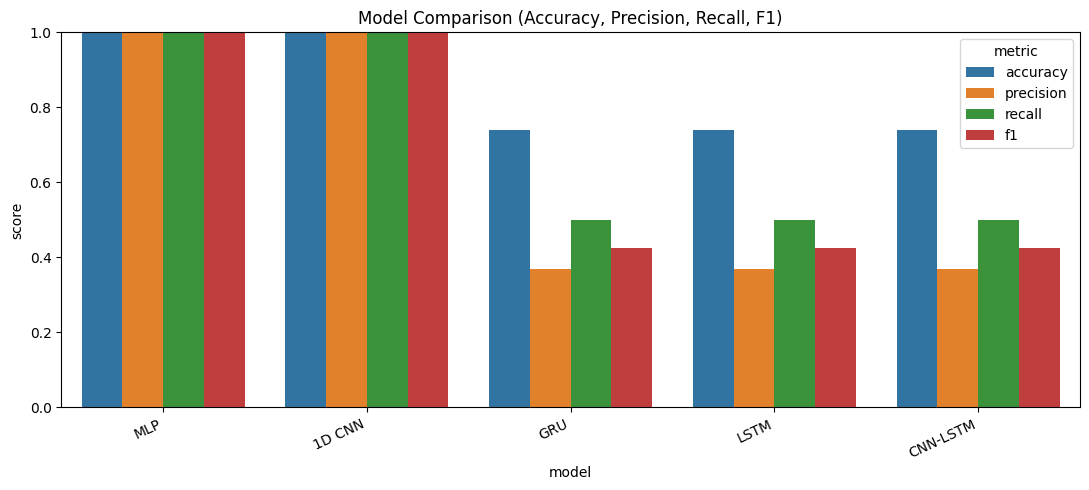

In [81]:
# ============================================================
# COMPARISON GRAPH (all 5 models in one chart)
# ============================================================
if not model_metrics:
    raise ValueError("model_metrics is empty. Run the model cells first.")

model_order = ["MLP", "1D CNN", "GRU", "LSTM", "CNN-LSTM"]
metrics_df = pd.DataFrame(model_metrics).T
available = [m for m in model_order if m in metrics_df.index]
missing = [m for m in model_order if m not in metrics_df.index]
if missing:
    print(f"Missing models in metrics: {missing}. Run those model cells first.")

metrics_df = metrics_df.loc[available]

plot_df = metrics_df[["accuracy", "precision", "recall", "f1"]].reset_index().rename(columns={"index": "model"})
plot_df = plot_df.melt(id_vars="model", var_name="metric", value_name="score")

plt.figure(figsize=(11, 5))
sns.barplot(data=plot_df, x="model", y="score", hue="metric")
plt.title("Model Comparison (Accuracy, Precision, Recall, F1)")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.legend(title="metric", loc="upper right")
plt.tight_layout()

results_dir = os.path.join("..", "results")
os.makedirs(results_dir, exist_ok=True)
comparison_path = os.path.join(results_dir, "sustainability_model_comparison.png")
plt.savefig(comparison_path, dpi=200, bbox_inches="tight")
print(f"Saved comparison chart to: {comparison_path}")
plt.show()

Saved bubble chart to: ..\results\sustainability_inference_training_ram.png


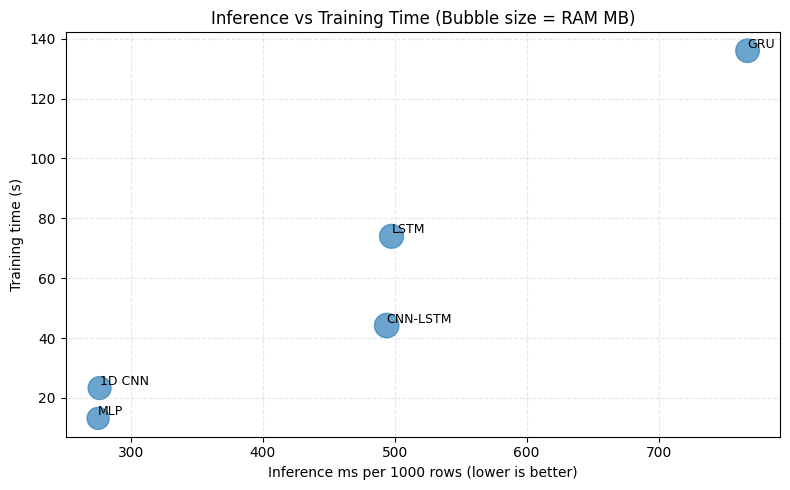

In [82]:
# ============================================================
# INFERENCE vs TRAINING TIME vs RAM (bubble chart)
# ============================================================
process = psutil.Process()

def _infer_time_ms_per_1000(model_obj, x_data):
    n = x_data.shape[0]
    if n == 0:
        return np.nan
    start = time.time()
    _ = model_obj.predict(x_data, verbose=0)
    elapsed = time.time() - start
    return (elapsed / n) * 1000 * 1000  # ms per 1000 rows

model_names = []
train_times = []
infer_ms_1k = []
ram_mb = []

# MLP
model_names.append("MLP")
train_times.append(train_time)
infer_ms_1k.append(_infer_time_ms_per_1000(model, X_test_proc))
ram_mb.append(process.memory_info().rss / (1024 * 1024))

# 1D CNN
model_names.append("1D CNN")
train_times.append(cnn_train_time)
infer_ms_1k.append(_infer_time_ms_per_1000(cnn_model, X_test_cnn))
ram_mb.append(process.memory_info().rss / (1024 * 1024))

# GRU
model_names.append("GRU")
train_times.append(gru_train_time)
infer_ms_1k.append(_infer_time_ms_per_1000(gru_model, X_test_gru))
ram_mb.append(process.memory_info().rss / (1024 * 1024))

# LSTM
model_names.append("LSTM")
train_times.append(lstm_train_time)
infer_ms_1k.append(_infer_time_ms_per_1000(lstm_model, X_test_lstm))
ram_mb.append(process.memory_info().rss / (1024 * 1024))

# CNN-LSTM
model_names.append("CNN-LSTM")
train_times.append(cnn_lstm_train_time)
infer_ms_1k.append(_infer_time_ms_per_1000(cnn_lstm_model, X_test_cnnlstm))
ram_mb.append(process.memory_info().rss / (1024 * 1024))

plt.figure(figsize=(8, 5))
sizes = [max(30, m) * 2 for m in ram_mb]
plt.scatter(infer_ms_1k, train_times, s=sizes, alpha=0.7, color="#2C7FB8")
for i, name in enumerate(model_names):
    plt.text(infer_ms_1k[i], train_times[i], name, fontsize=9, ha="left", va="bottom")

plt.title("Inference vs Training Time (Bubble size = RAM MB)")
plt.xlabel("Inference ms per 1000 rows (lower is better)")
plt.ylabel("Training time (s)")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()

results_dir = os.path.join("..", "results")
os.makedirs(results_dir, exist_ok=True)
bubble_path = os.path.join(results_dir, "sustainability_inference_training_ram.png")
plt.savefig(bubble_path, dpi=200, bbox_inches="tight")
print(f"Saved bubble chart to: {bubble_path}")
plt.show()

In [87]:
# ============================================================
# SAVE METRICS + BEST MODEL SUMMARY TO RESULTS/
# ============================================================
if not model_metrics:
    raise ValueError("model_metrics is empty. Run the model cells first.")

results_dir = os.path.join("..", "results")
os.makedirs(results_dir, exist_ok=True)

metrics_df = pd.DataFrame(model_metrics).T
metrics_df = metrics_df.sort_values(by="accuracy", ascending=False)
metrics_path = os.path.join(results_dir, "sustainability_metrics.csv")
metrics_df.to_csv(metrics_path, index=True)
print(f"Saved metrics to: {metrics_path}")

best_model_name = metrics_df.index[0]
best_row = metrics_df.iloc[0]
best_shap_name = best_model_name.lower().replace(" ", "_").replace("-", "_")
best_shap_path = f"sustainability_shap_best_{best_shap_name}.png"
summary_lines = [
    "Sustainability Classification Results",
    "====================================",
    f"Best model: {best_model_name}",
    f"Accuracy: {best_row['accuracy']:.4f}",
    f"Precision (macro): {best_row['precision']:.4f}",
    f"Recall (macro): {best_row['recall']:.4f}",
    f"F1 (macro): {best_row['f1']:.4f}",
    "",
    "All model metrics saved in sustainability_metrics.csv",
    "Charts saved:",
    "- sustainability_model_comparison.png",
    "- sustainability_inference_training_ram.png",
    "",
    "Best-model SHAP plot:",
    f"- {best_shap_path}",
    "",
    "Model artifact:",
    "- models/sustainability_model.pkl (MLP)",
]
summary_path = os.path.join(results_dir, "sustainability_results_summary.txt")
with open(summary_path, "w", encoding="utf-8") as f:
    f.write("\n".join(summary_lines))
print(f"Saved summary to: {summary_path}")

Saved metrics to: ..\results\sustainability_metrics.csv
Saved summary to: ..\results\sustainability_results_summary.txt


Best model for SHAP: MLP
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


  0%|          | 0/20 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


  5%|▌         | 1/20 [00:00<00:09,  2.10it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


 95%|█████████▌| 19/20 [00:10<00:00,  1.87it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


100%|██████████| 20/20 [00:10<00:00,  1.88it/s]


Saved SHAP plot to: ..\results\sustainability_shap_best_mlp.png


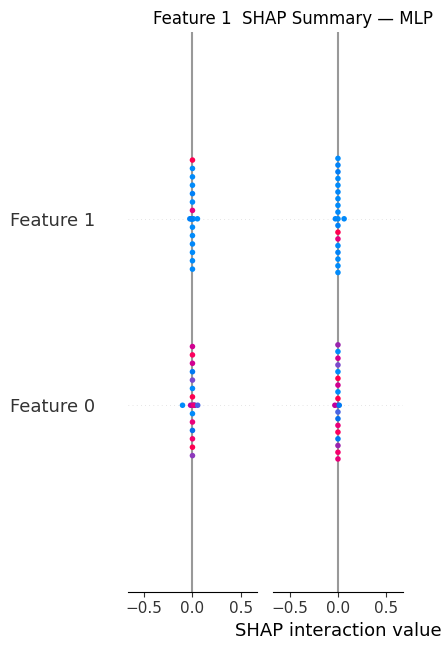

In [86]:
# ============================================================
# SHAP EXPLANATIONS FOR BEST MODEL ONLY (lightweight)
# ============================================================
def _sample_rows(array_like, n):
    n = min(n, array_like.shape[0])
    idx = np.random.choice(array_like.shape[0], n, replace=False)
    return array_like[idx]

def _shap_kernel_tabular(model_predict, background, explain, title, save_path=None):
    explainer = shap.KernelExplainer(model_predict, background)
    shap_values = explainer.shap_values(explain, nsamples=100)
    shap.summary_plot(shap_values, explain, show=False)
    plt.title(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"Saved SHAP plot to: {save_path}")
    plt.show()

def _make_seq_predictor(model_obj, timesteps):
    def _predict(flat_x):
        reshaped = flat_x.reshape(flat_x.shape[0], timesteps, 1)
        return model_obj.predict(reshaped, verbose=0)
    return _predict

def _flatten_3d(arr_3d):
    return arr_3d.reshape(arr_3d.shape[0], -1)

if not model_metrics:
    raise ValueError("model_metrics is empty. Run the model cells first.")

metrics_df = pd.DataFrame(model_metrics).T
best_model_name = metrics_df["accuracy"].idxmax()
print(f"Best model for SHAP: {best_model_name}")

results_dir = os.path.join("..", "results")
os.makedirs(results_dir, exist_ok=True)

# Prepare SHAP inputs based on the best model
if best_model_name == "MLP":
    bg = _sample_rows(X_train_proc, 50)
    explain = _sample_rows(X_test_proc, 20)
    predictor = model.predict
    title = "SHAP Summary — MLP"
    shap_path = os.path.join(results_dir, "sustainability_shap_best_mlp.png")
elif best_model_name == "1D CNN":
    bg = _flatten_3d(_sample_rows(X_train_cnn, 30))
    explain = _flatten_3d(_sample_rows(X_test_cnn, 15))
    predictor = _make_seq_predictor(cnn_model, X_train_cnn.shape[1])
    title = "SHAP Summary — 1D CNN"
    shap_path = os.path.join(results_dir, "sustainability_shap_best_1d_cnn.png")
elif best_model_name == "GRU":
    bg = _flatten_3d(_sample_rows(X_train_gru, 30))
    explain = _flatten_3d(_sample_rows(X_test_gru, 15))
    predictor = _make_seq_predictor(gru_model, X_train_gru.shape[1])
    title = "SHAP Summary — GRU"
    shap_path = os.path.join(results_dir, "sustainability_shap_best_gru.png")
elif best_model_name == "LSTM":
    bg = _flatten_3d(_sample_rows(X_train_lstm, 30))
    explain = _flatten_3d(_sample_rows(X_test_lstm, 15))
    predictor = _make_seq_predictor(lstm_model, X_train_lstm.shape[1])
    title = "SHAP Summary — LSTM"
    shap_path = os.path.join(results_dir, "sustainability_shap_best_lstm.png")
elif best_model_name == "CNN-LSTM":
    bg = _flatten_3d(_sample_rows(X_train_cnnlstm, 30))
    explain = _flatten_3d(_sample_rows(X_test_cnnlstm, 15))
    predictor = _make_seq_predictor(cnn_lstm_model, X_train_cnnlstm.shape[1])
    title = "SHAP Summary — CNN-LSTM"
    shap_path = os.path.join(results_dir, "sustainability_shap_best_cnn_lstm.png")
else:
    raise ValueError(f"Unknown best model name: {best_model_name}")

_shap_kernel_tabular(predictor, bg, explain, title, shap_path)